# Статистика, DS-поток
## Марафон-домашка SM.5, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Баллы за задание:**

* Задача 1 &mdash; 50 баллов;
* Задача 2 &mdash; 40 баллов;
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 30 баллов;
* Задача 6 &mdash; 60 баллов.

**Важность задач:**

* *высокая:* задачи 1, 2, 6;
* *средняя:* задача 4, 5;
* *обычная:* задача 3.

In [ ]:
# Bot check

# HW_ID: ds_sm5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set(style="whitegrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
import kagglehub
import os
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

______________
### Задача 1.
В этой задаче нужно сделать оценку максимального правдоподобия для многомерного нормального распределения по датасету химического анализа вин трех разных сортов в Италии.
Скачайте данные по ссылке https://archive.ics.uci.edu/ml/datasets/wine (файл `wine.data`) и загрузите их с помощью библиотеки pandas.

In [4]:
df = pd.read_csv("wine.data", header=None)
df.columns = [
    "Class",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline"
]

df.head(3)

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185


Пусть выборка $X = (X_1, ..., X_n)$ такова, что каждый ее элемент имеет многомерное нормальное распределение со средним вектором $a \in \mathbb {R} ^d$ и матрицей ковариаций $\Sigma \in \mathbb {R} ^ {d \times d}$.

Запишите оценку максимального правдоподобия для параметров $a$ и $\Sigma$.

**Ответ:** См. SM4t, №4:

$$
\boxed{
\widehat{a} = \bar{X},
\qquad
\widehat{\Sigma} = \frac{1}{n} \sum_{i=1}^n (X_i - \bar{X})(X_i - \bar{X})^\top
}
$$


Рассмотрим колонки "Alcalinity of ash", "Nonflavanoid phenols", "Proanthocyanins", "Hue" для всех сортов вина вместе.
Предположим, что данные в них образуют выборку из многомерного нормального распределения с неизвестными параметрами, которые вам нужно оценить.

Визуализируйте рассматриваемые данные с помощью `seaborn.pairplot`, чтобы убедиться в том, что данные визуально похожи на нормальное распределение:

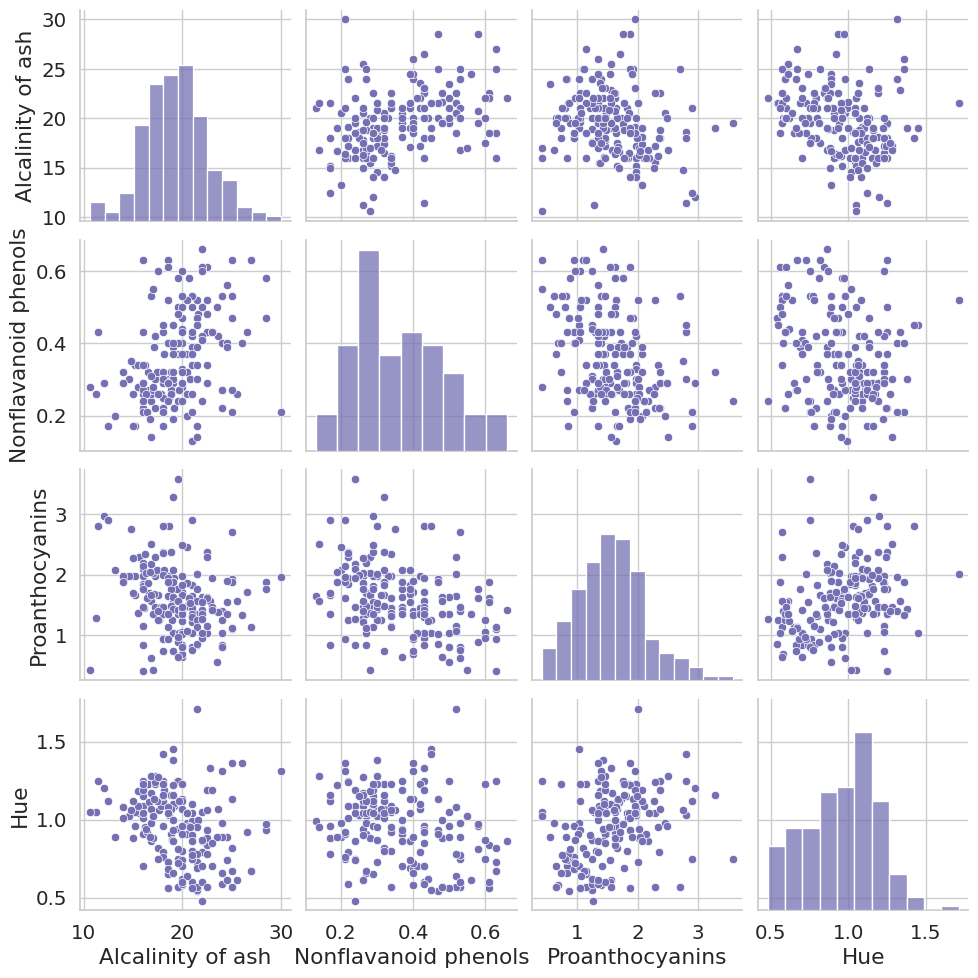

,Alcalinity of ash,Nonflavanoid phenols,Proanthocyanins,Hue
0,15.6,0.28,2.29,1.04
1,11.2,0.26,1.28,1.05
2,18.6,0.30,2.81,1.03
3,16.8,0.24,2.18,0.86
4,21.0,0.39,1.82,1.04
...,...,...,...,...
173,20.5,0.52,1.06,0.64
174,23.0,0.43,1.41,0.70
175,20.0,0.43,1.35,0.59
176,20.0,0.53,1.46,0.60


In [221]:
X = df.loc[:, ["Alcalinity of ash", "Nonflavanoid phenols", "Proanthocyanins", "Hue"]]
sns.pairplot(X)
plt.show()
X

Напишите функцию подсчета оценки максимального правдоподобия для вектора средних $a$ и матрицы ковариаций $\Sigma$ по выборке. Использование циклов наказуемо.

In [223]:
def mle_for_mean(sample):
    '''
    :param sample: выборка из многомерного нормального распределения
    :return: ОМП для вектора средних
    '''
    X_mean = np.mean(sample, axis=0)
    return X_mean

In [224]:
def mle_for_covariance_matrix(sample):
    '''
    :param sample: выборка из многомерного нормального распределения
    :return: ОМП для матрицы ковариаций
    '''

    n = sample.shape[0]
    X_mean = np.mean(sample, axis=0)
    X_centered = sample - X_mean[None, :]
    
    return 1 / n * X_centered.T @ X_centered # Можно (X_centered[None] * X_centered[None].T).mean(axis=1)

In [226]:
X_values = X.values
a = mle_for_mean(X_values)
sigma = mle_for_covariance_matrix(X_values)

Визуализируйте полученный результат. Для каждой пары признаков постройте информативный график, на котором будут:

1. Точки выборки.

2. Плотность нормального распределения с оцененными параметрами, которую изобразите в виде линий уровня.

*Указание.* Используйте функции `plt.pcolormesh` и `plt.clabel`

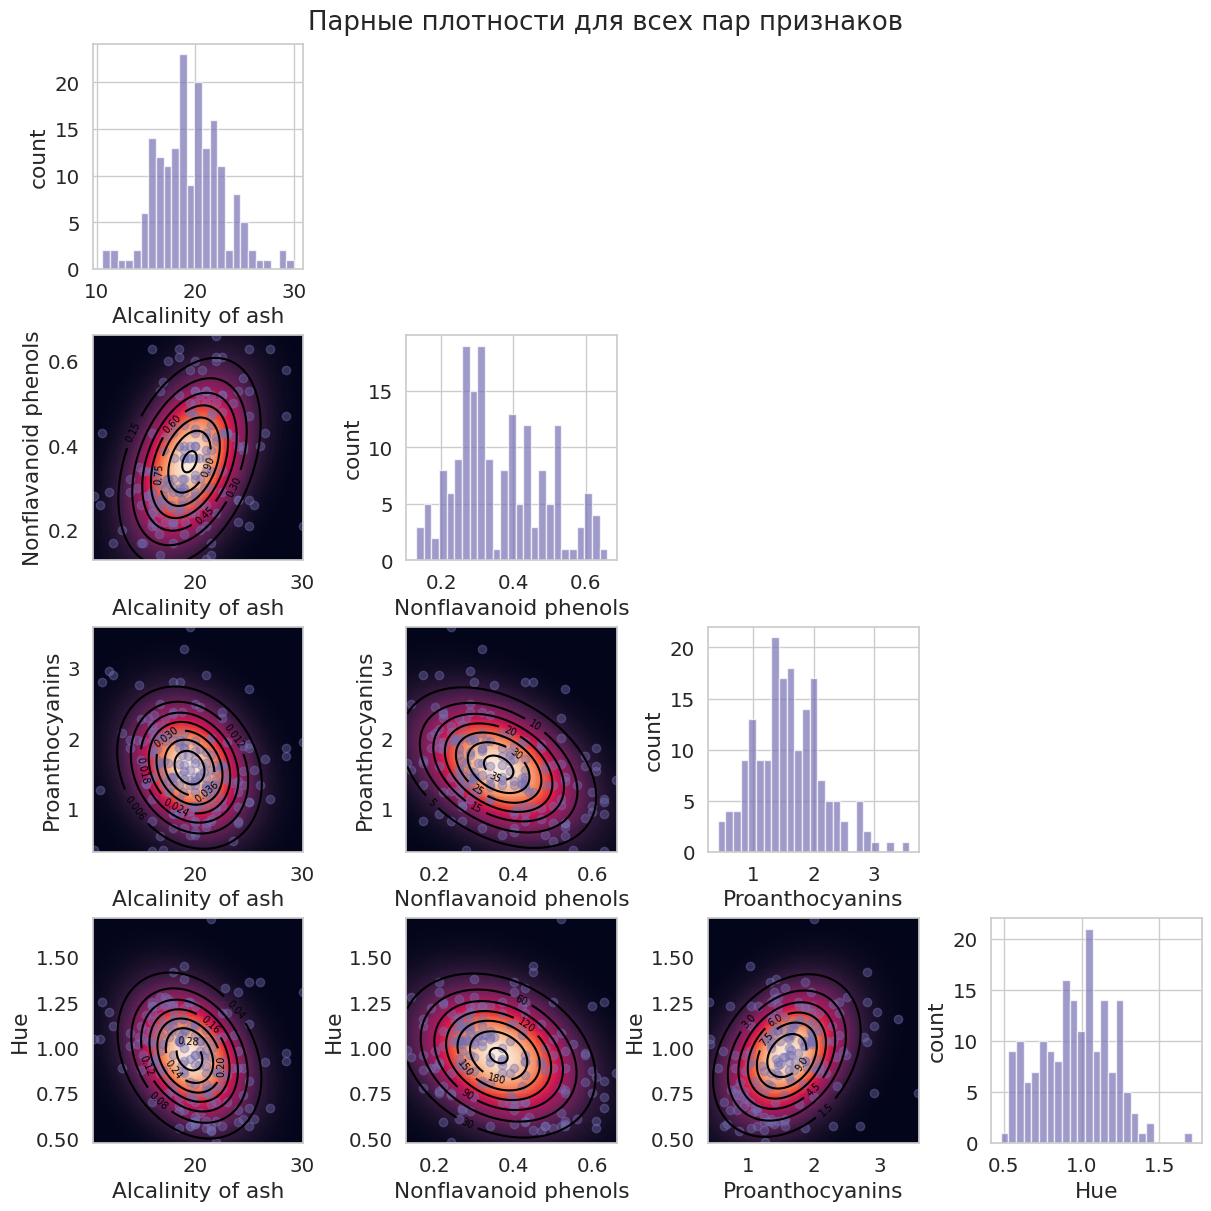

In [293]:
cols = ['Alcalinity of ash', 'Nonflavanoid phenols', 'Proanthocyanins', 'Hue']
df_sub = df[cols]
sample = df_sub.values       
n, p = sample.shape

a = mle_for_mean(sample)                
sigma = mle_for_covariance_matrix(sample)  

def gaussian_pdf_grid_2d(A, B, mean2, sigma2):
    pos = np.stack([A, B], axis=-1)       
    diff = pos - mean2                    
    inv_sigma = np.linalg.inv(sigma2)      
    det_sigma = np.linalg.det(sigma2)
    q = np.einsum('...i,ij,...j->...', diff, inv_sigma, diff)
    Z = 1 / (2 * np.pi * det_sigma) * np.exp(-0.5 * q)
    return Z

fig, axes = plt.subplots(p, p, figsize=(3*p, 3*p), constrained_layout=True)

for i in range(p):
    for j in range(p):
        ax = axes[i, j]
        if i == j:
            ax.hist(df_sub[cols[i]].values, bins=25, alpha=0.7)
            ax.set_xlabel(cols[j])
            ax.set_ylabel('count')
        elif i < j:
            ax.axis('off')
        else:
            x = df_sub[cols[j]].values
            y = df_sub[cols[i]].values
            
            x_grid = np.linspace(x.min(), x.max(), grid_res)
            y_grid = np.linspace(y.min(), y.max(), grid_res)
            A, B = np.meshgrid(x_grid, y_grid)
            mean2 = a[[j, i]] 
            sigma2 = sigma[np.ix_([j, i], [j, i])]
            Z = gaussian_pdf_grid_2d(A, B, mean2, sigma2)

            pcm = ax.pcolormesh(A, B, Z)
            contours = ax.contour(A, B, Z, colors='k')
            ax.clabel(contours, fontsize=7)
            ax.scatter(x, y, alpha=0.4)
            ax.set_xlabel(cols[j])
            ax.set_ylabel(cols[i])

plt.suptitle('Парные плотности для всех пар признаков')
plt.show()

**Вывод:** MLE даёт неплохуй оценку распрделения многомерных нормальных признаков

___
### Задача 2.

Для данных из задачи ML.4.4 рассмотрим две модели: случайный лес и ридж-регрессия. Постройте бутстрепные доверительные интервалы трех типов для метрик MSE, MAE, MAPE этих двух моделей.

**Решение:**

In [2]:
path = kagglehub.dataset_download("camnugent/california-housing-prices")
data = pd.read_csv(os.path.join(path, "housing.csv"))
data = pd.get_dummies(data)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
data = pd.DataFrame(data=imputer.fit_transform(data), columns=data.columns)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [3]:
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
ridge = Ridge(random_state=RANDOM_STATE)

rf.fit(X_train, y_train)
ridge.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test)
ridge_pred = ridge.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mape = mean_absolute_percentage_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)

print("Random Forest:")
print(f"MAE: {rf_mae:.4f}")
print(f"MAPE: {rf_mape:.4f}")
print(f"MSE: {rf_mse:.4f}\n")

print("Ridge:")
print(f"MAE: {ridge_mae:.4f}")
print(f"MAPE: {ridge_mape:.4f}")
print(f"MSE: {ridge_mse:.4f}")

Random Forest:
MAE: 31443.4841
MAPE: 0.1783
MSE: 2366209340.0466

Ridge:
MAE: 50302.0057
MAPE: 0.2921
MSE: 4796477041.7847


In [6]:
n = rf_pred.size
b = 100_000
ind = np.random.randint(0, n, size=(b, n))

errors = abs(rf_pred[ind] - y_test.to_numpy()[ind])
maes = np.mean(errors, axis=1)

v_boot = np.var(maes)

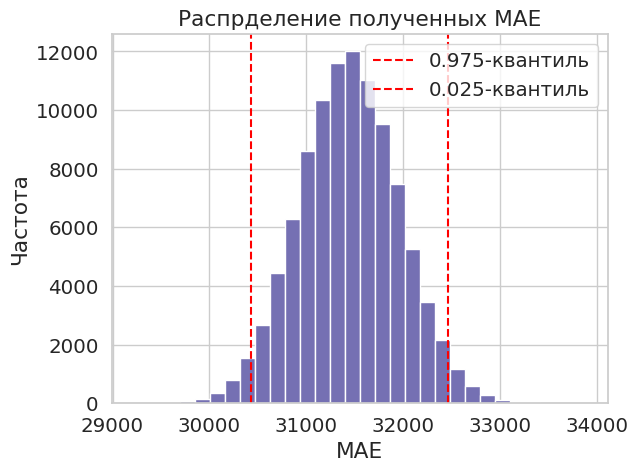

In [8]:
alpha = 0.95
plt.hist(maes, bins=30)
plt.title('Распрделение полученных MAE')
q1, q2 = np.quantile(maes, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MAE')
plt.ylabel('Частота')
plt.show()

In [9]:
z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({rf_mae - z * np.sqrt(v_boot):.2f}, '
    f'{rf_mae + z * np.sqrt(v_boot):.2f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * rf_mae - q2:.2f}, {2 * rf_mae - q1:.2f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.2f}, {q2:.2f})'
)

Нормальный ДИ:
   (30430.54, 32456.42)
Центральный ДИ:
   (30428.91, 32454.29)
Квантильный ДИ:
   (30432.68, 32458.06)


In [6]:
n = rf_pred.size
b = 100_000
ind = np.random.randint(0, n, size=(b, n))

errors = np.abs((rf_pred[ind] - y_test.to_numpy()[ind]) / y_test.to_numpy()[ind])
mapes = np.mean(errors, axis=1)

v_boot = np.var(mapes)

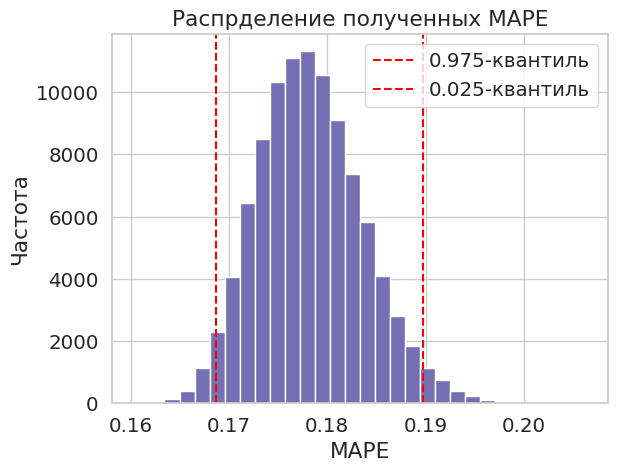

In [7]:
alpha = 0.95
plt.hist(mapes, bins=30)
plt.title('Распрделение полученных MAPE')
q1, q2 = np.quantile(mapes, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MAPE')
plt.ylabel('Частота')
plt.show()

In [10]:
alpha = 0.95
z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({rf_mape - z * np.sqrt(v_boot):.4f}, '
    f'{rf_mape + z * np.sqrt(v_boot):.4f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * rf_mape - q2:.4f}, {2 * rf_mape - q1:.4f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.4f}, {q2:.4f})'
)

Нормальный ДИ:
   (0.1677, 0.1888)
Центральный ДИ:
   (0.1668, 0.1878)
Квантильный ДИ:
   (0.1687, 0.1897)


In [10]:
n = rf_pred.size
b = 100_000
ind = np.random.randint(0, n, size=(b, n))

errors = (rf_pred[ind] - y_test.to_numpy()[ind]) ** 2
mses = np.mean(errors, axis=1)

v_boot = np.var(mses)

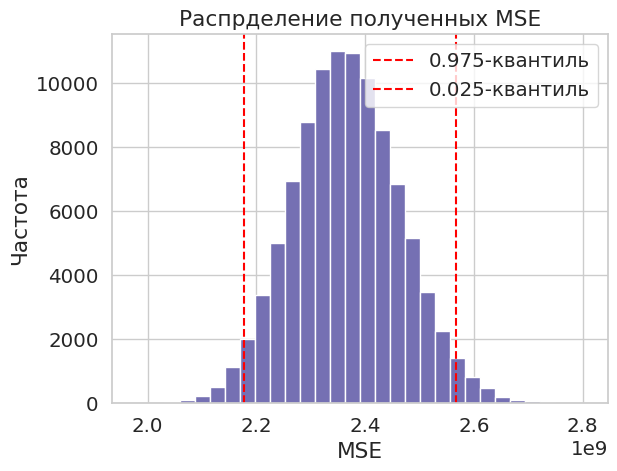

In [11]:
alpha = 0.95
plt.hist(mses, bins=30)
plt.title('Распрделение полученных MSE')
q1, q2 = np.quantile(mses, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MSE')
plt.ylabel('Частота')
plt.show()

In [13]:
z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({rf_mse - z * np.sqrt(v_boot):.2f}, '
    f'{rf_mse + z * np.sqrt(v_boot):.2f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * rf_mse - q2:.2f}, {2 * rf_mse - q1:.2f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.2f}, {q2:.2f})'
)

Нормальный ДИ:
   (2171679007.56, 2560739672.53)
Центральный ДИ:
   (2165948322.02, 2555207789.60)
Квантильный ДИ:
   (2177210890.49, 2566470358.07)


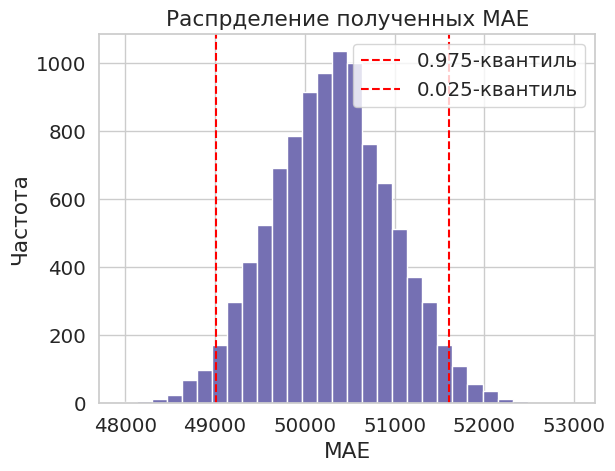

Нормальный ДИ:
   (48993.50, 51610.51)
Центральный ДИ:
   (48993.10, 51592.85)
Квантильный ДИ:
   (49011.16, 51610.91)


In [6]:
n = ridge_pred.size
b = 10_000
ind = np.random.randint(0, n, size=(b, n))

errors = abs(ridge_pred[ind] - y_test.to_numpy()[ind])
maes = np.mean(errors, axis=1)

v_boot = np.var(maes)

alpha = 0.95
plt.hist(maes, bins=30)
plt.title('Распрделение полученных MAE')
q1, q2 = np.quantile(maes, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MAE')
plt.ylabel('Частота')
plt.show()

z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({ridge_mae - z * np.sqrt(v_boot):.2f}, '
    f'{ridge_mae + z * np.sqrt(v_boot):.2f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * ridge_mae - q2:.2f}, {2 * ridge_mae - q1:.2f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.2f}, {q2:.2f})'
)

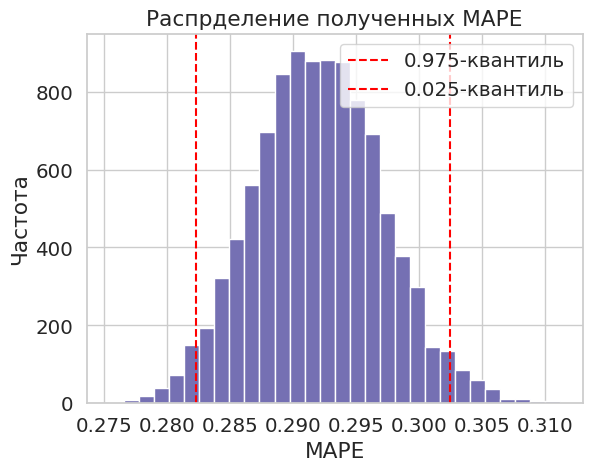

Нормальный ДИ:
   (0.2821, 0.3021)
Центральный ДИ:
   (0.2816, 0.3019)
Квантильный ДИ:
   (0.2823, 0.3025)


In [11]:
n = ridge_pred.size
b = 10_000
ind = np.random.randint(0, n, size=(b, n))

errors = np.abs((ridge_pred[ind] - y_test.to_numpy()[ind]) / y_test.to_numpy()[ind])
maes = np.mean(errors, axis=1)

v_boot = np.var(maes)

alpha = 0.95
plt.hist(maes, bins=30)
plt.title('Распрделение полученных MAPE')
q1, q2 = np.quantile(maes, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MAPE')
plt.ylabel('Частота')
plt.show()

z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({ridge_mape - z * np.sqrt(v_boot):.4f}, '
    f'{ridge_mape + z * np.sqrt(v_boot):.4f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * ridge_mape - q2:.4f}, {2 * ridge_mape - q1:.4f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.4f}, {q2:.4f})'
)

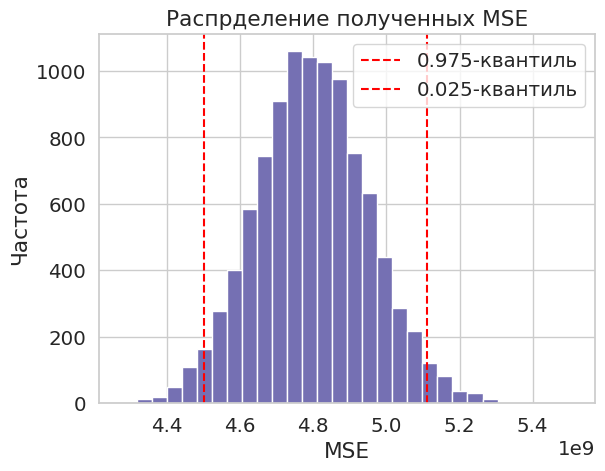

Нормальный ДИ:
   (4796477041.77, 4796477041.79)
Центральный ДИ:
   (4481046193.58, 5091012280.96)
Квантильный ДИ:
   (4501941802.61, 5111907889.99)


In [14]:
n = ridge_pred.size
b = 10_000
ind = np.random.randint(0, n, size=(b, n))

errors = (ridge_pred[ind] - y_test.to_numpy()[ind]) ** 2
mses = np.mean(errors, axis=1)

v_boot = np.var(maes)

alpha = 0.95
plt.hist(mses, bins=30)
plt.title('Распрделение полученных MSE')
q1, q2 = np.quantile(mses, [(1 - alpha) / 2, (1 + alpha) / 2])
plt.axvline(q1, label=f'{(1 + alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.axvline(q2, label=f'{(1 - alpha) / 2:.3f}-квантиль', color='r', linestyle='--')
plt.legend()
plt.xlabel('MSE')
plt.ylabel('Частота')
plt.show()

z = sps.norm.ppf((1 + alpha) / 2)

print(
    f'Нормальный ДИ:\n'
    f'   ({ridge_mse - z * np.sqrt(v_boot):.2f}, '
    f'{ridge_mse + z * np.sqrt(v_boot):.2f})'
)

print(
    f'Центральный ДИ:\n'
    f'   ({2 * ridge_mse - q2:.2f}, {2 * ridge_mse - q1:.2f})'
)

print(
    f'Квантильный ДИ:\n'
    f'   ({q1:.2f}, {q2:.2f})'
)

**Вывод:** Все 3 вида ДИ получились примерно совпадающими

___
### Задача 3.

Сгенерируйте выборку $X_1, ..., X_{10000}$ из стандартного нормального распределения. Для каждого $n \leqslant 10000$ постройте эмпирическую функцию распределения $\widehat{F}_n$ и посчитайте **точное** значение статистики 

$$D_n = \sup\limits_{x \in \mathbb{R}} \left| \widehat{F}_n(x) - F(x) \right|.$$

Обоснуйте, почему при вашей реализации подсчета статистики полученное значение будет **точным**.

Постройте график зависимости статистики $D_n$ от $n$. Верно ли, что $D_n \to 0$ и в каком смысле?


Для выполнения задания можно использовать `statsmodels.distributions.empirical_distribution.ECDF`.

Промежутки между ступентками эмпирической функции распрделения одинаковы и равны 1/n. Функция распрделения возрастает, а эмпирическая функция распрделения - кусочно-постоянно. Значит максимальная разница может быть только в точках выборки, в правом и левом её пределе

In [22]:
from statsmodels.distributions.empirical_distribution import ECDF

In [76]:
n = 10_000
sample = sps.norm.rvs(size=n)
F_hat = ECDF(sample)
F = sps.norm.cdf
max1 = np.max(np.abs(F_hat(sample) - F(sample)))
max2 = np.max(np.abs(F_hat(sample[1:]) - F(sample[1:] - 1 / n)))
print(f'D = {max(max1, max2):.4f}')

n_range = np.arange(2, n + 1)
D_n = []

for n in tqdm(n_range):
    sample = sps.norm.rvs(size=n)
    F_hat = ECDF(sample)
    F = sps.norm.cdf
    max1 = np.max(np.abs(F_hat(sample) - F(sample)))
    max2 = np.max(np.abs(F_hat(sample[1:]) - F(sample[1:] - 1 / n)))
    D_n.append(max(max1, max2))

D = 0.0110


  0%|          | 0/9999 [00:00<?, ?it/s]

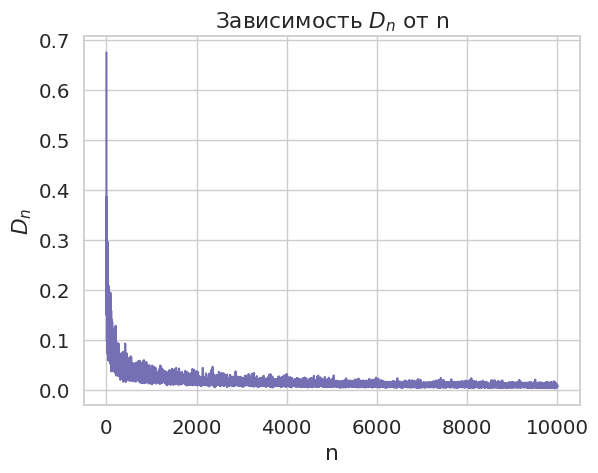

In [81]:
plt.plot(n_range, D_n)
plt.title('Зависимость $D_n$ от n')
plt.xlabel('n')
plt.ylabel(r'$D_n$')
plt.show()

**Вывод:** Видим, что $D_n \to 0$. Все линии сходятся к нулю с шумом, который затухает, поэтому сходимость почти наверное, что согласуется с теоремой Гливенко — Кантелли.

---

### Задача 4.

В этой задаче вы исследуете различные непараметрические оценки распределений.
Для этого вам выдается почти готовый код функций `draw_ecdf`, `draw_hist` и `draw_pdf`, которые используются для построения ЭФР, гистограммы и ядерной оценки плотности соответственно. В реализациях этих функция часть кода пропущена, вам нужно его дописать. Код предполагает использование реализации ядерных оценок плотности из `statsmodels`.
При желании вы можете написать аналогичный код, используя реализацию в `seaborn`.

In [19]:
from statsmodels.nonparametric.kde import KDEUnivariate

In [23]:
def draw_ecdf(sample, grid, cdf=None):
    """
    По сетке cтроит графики эмпирической функции распределения 
    и истинной (если она задана) для всей выборки и для 1/10 ее части.
    
    Вход:
        sample: выборка
        grid: сетка
        cdf: истинная функция распределения из scipy.stats
    """
    
    plt.figure(figsize=(16, 3))
    # Выбирается размер выборки
    for i, size in enumerate([len(sample) // 10, len(sample)]):
        plt.subplot(1, 2, i + 1)
        
        # Отрисовываются точки выборки на графике    
        plt.scatter(
            sample[:size], np.zeros(size),
            alpha=0.4, label='sample'
        )
        
        # Если передана истинная функция распределения, 
        # отрисовывается ее график
        if cdf is not None:
            plt.plot(
                grid,
                cdf(grid),
                color='green', alpha=0.3, lw=2, label='true cdf'
            )
        
        # Отрисовывается эмпирическую функцию распределения
        plt.plot(
            grid,
            ECDF(sample[:size])(grid),
            color='red', label='ecdf'
        )
        
        plt.legend()
        plt.grid(ls=':')
        plt.title('sample size = {}'.format(size))
    plt.show()

In [18]:
def draw_hist(sample, grid, pdf=None):
    """
    Строит гистограмму и, по сетке, график истинной плотности 
    (если она задана) для всей выборки и для 1/10 ее части.
    
    Вход:
        sample: выборка
        grid: сетка
        pdf: истинная плотность из scipy.stats
    """
    
    plt.figure(figsize=(16, 3))
    # Выбирается размер выборки
    for i, size in enumerate([len(sample) // 10, len(sample)]):
        plt.subplot(1, 2, i + 1)
        
        # Построение гистограммы для выборки
        plt.hist(
            sample[:size], 
            bins=20,
            range=(grid.min(), grid.max()),
            density=True, label='sample hist'
        )
        
        # Если передана истинная плотность, отрисовывается ее график
        if pdf is not None:
            plt.plot(
                grid,
                pdf(grid),
                color='green', alpha=0.3, lw=2, label='true pdf'
            )
        
        plt.legend()
    plt.show()

In [20]:
def draw_pdf(sample, grid, pdf=None):
    """
    По сетке cтроит графики ядерной оценки плотности 
    и истинной плотности (если она задана) для всей выборки 
    и для 1/10 ее части.
    
    Вход:
        sample: выборка
        grid: сетка
        pdf: истинная плотность из scipy.stats
    """
    
    plt.figure(figsize=(16, 3))
    # Выбирается размер выборки
    for i, size in enumerate([len(sample) // 10, len(sample)]):
        plt.subplot(1, 2, i + 1)
        
        # Отрисовка точек выборки на графике
        plt.scatter(
            sample[:size], np.zeros(size), 
            alpha=0.4, label='sample'
        )
        
        # Если передана истинная плотность, отрисовывается ее график
        if pdf is not None:
            plt.plot(
                grid,
                pdf(grid), 
                color='green', alpha=0.3, lw=2, label='true pdf'
            )
        
        # Отрисовывается KDE
        plt.plot(
            grid,
            KDEUnivariate(sample[:size]).fit().evaluate(grid),
            color='red', label='kde'
        )
        
        plt.legend()
        plt.grid(ls=':')
    plt.show()

Используя реализованные выше функции, постройте график эмпирической функции распределения (ЭФР), гистограмму и график ядерной оценки плотнотности к выборкам размера 500 для следующих распределений:

In [15]:
n = 500
m = 300

**1.** *Равномерное распределение $U[0,1]$*. Графики функции распределения и плотностей строить на интервале $(-0.2, 1.2)$.

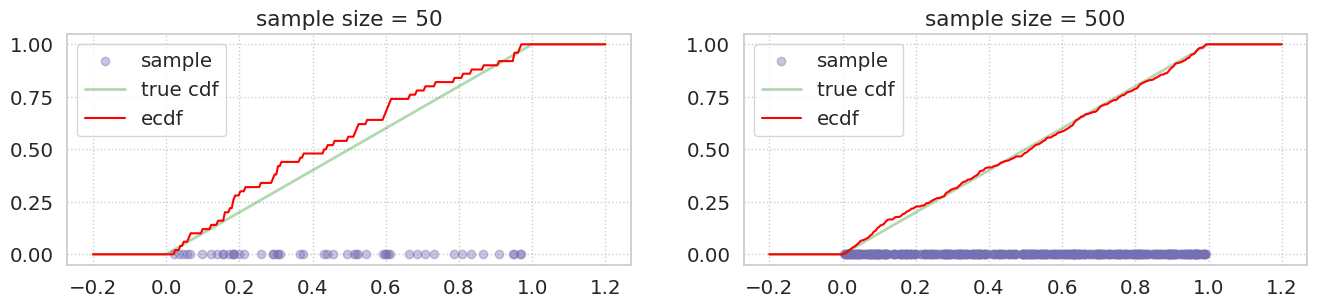

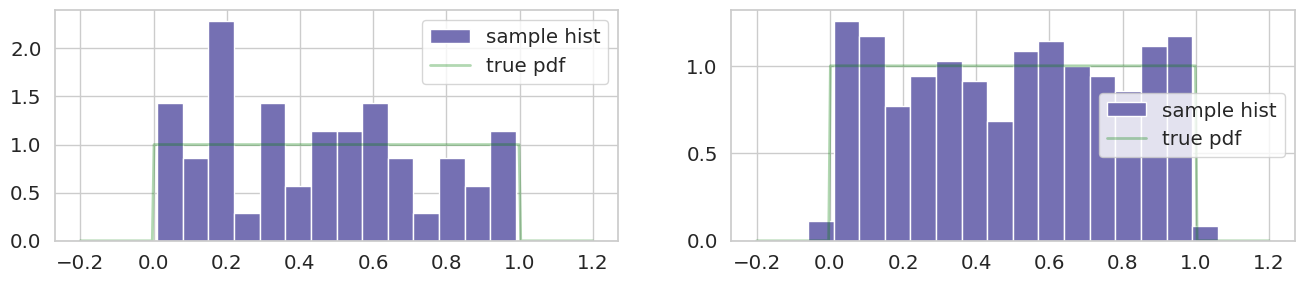

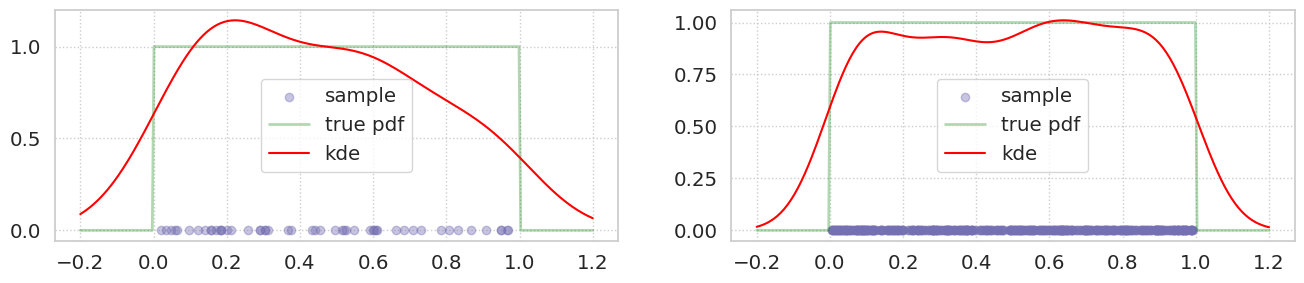

In [29]:
sample = sps.uniform.rvs(size=n, random_state=RANDOM_STATE)
grid = np.linspace(-0.2, 1.2, m)
F = sps.uniform.cdf
f = sps.uniform.pdf

draw_ecdf(sample, grid, F)
draw_hist(sample, grid, f)
draw_pdf(sample, grid, f)

**2.** *Нормальное распределение $\mathcal{N}(0, 1)$.* Графики функции распределения и плотностей строить на интервале $(-3, 3)$.

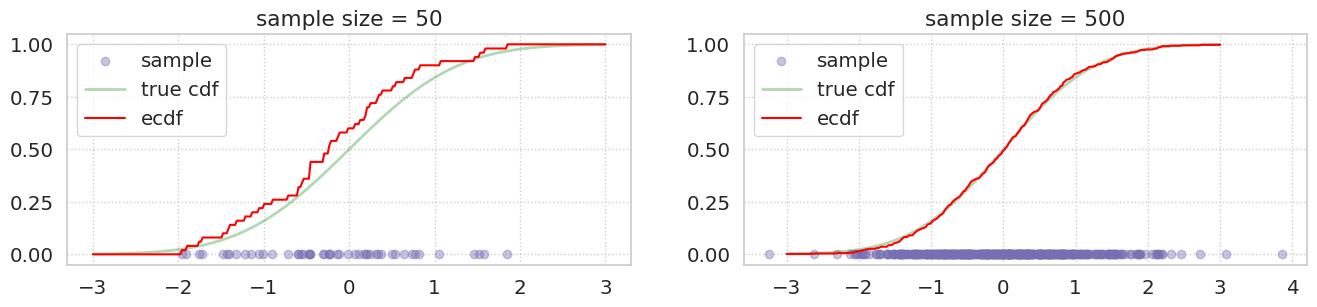

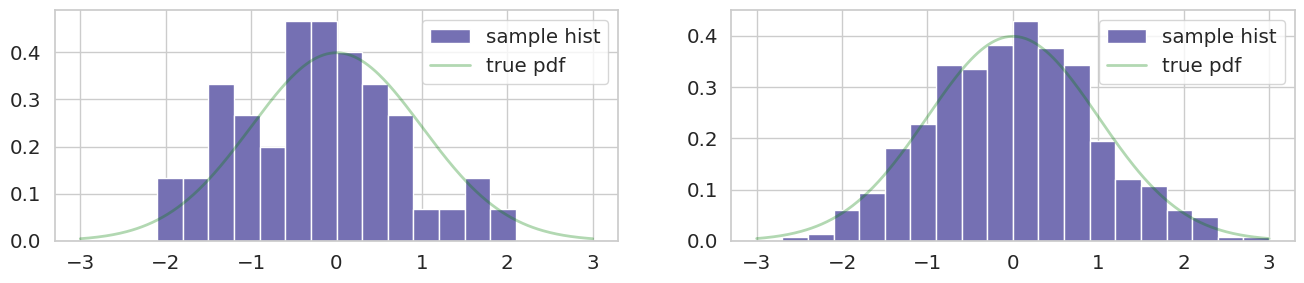

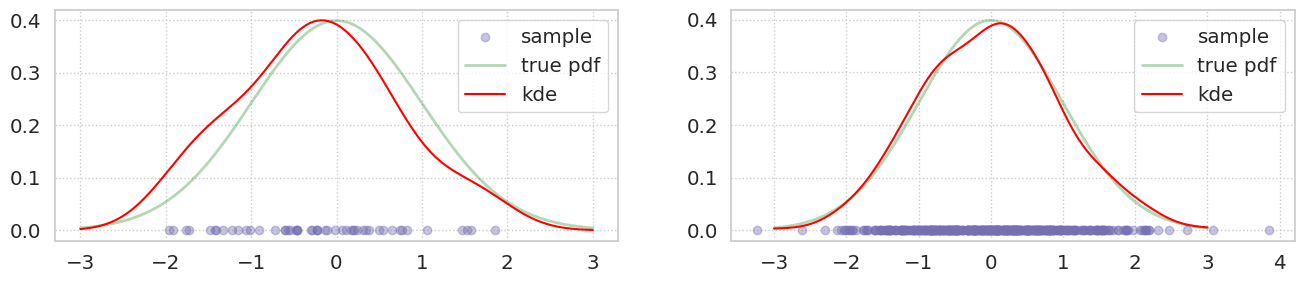

In [30]:
sample = sps.norm.rvs(size=n, random_state=RANDOM_STATE)
grid = np.linspace(-3, 3, m)
F = sps.norm.cdf
f = sps.norm.pdf

draw_ecdf(sample, grid, F)
draw_hist(sample, grid, f)
draw_pdf(sample, grid, f)

**3.** *Экспоненциальное распределение $Exp(1)$.* Графики функции распределения и плотностей  строить на интервале $(-0.5, 5)$.

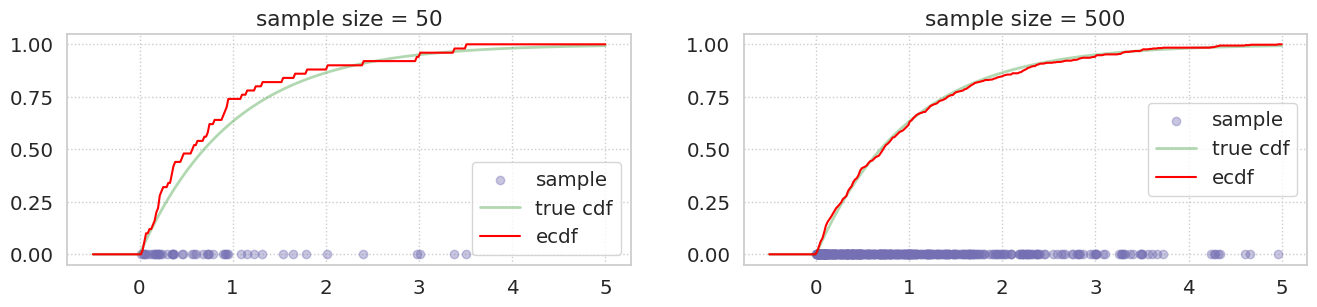

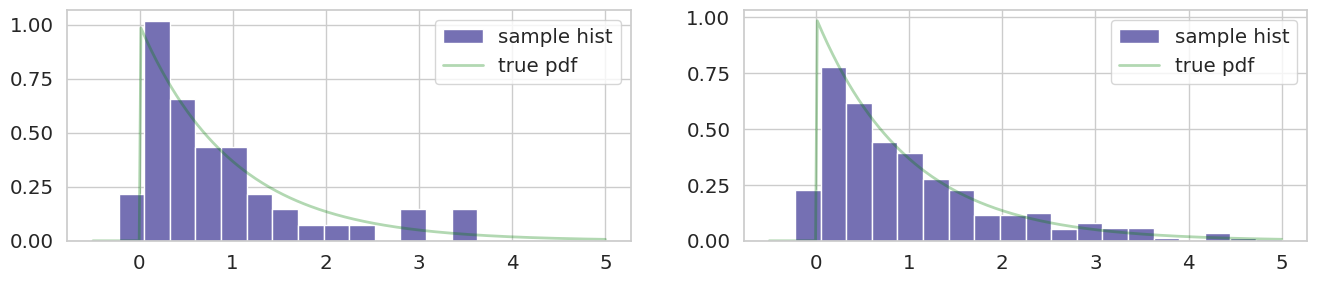

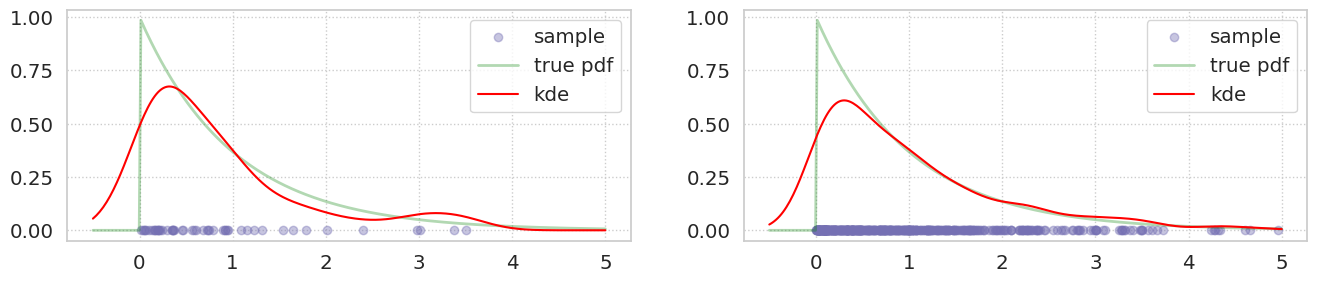

In [31]:
sample = sps.expon.rvs(size=n, random_state=RANDOM_STATE)
grid = np.linspace(-0.5, 5, m)
F = sps.expon.cdf
f = sps.expon.pdf

draw_ecdf(sample, grid, F)
draw_hist(sample, grid, f)
draw_pdf(sample, grid, f)

Опишите полученные результаты, сравните их между выборками из различных распределений.

**Вывод:** Видим, что, как и ожидалось, все выборочные характеристики с ростом выборки сходтся к истинным. Самые большие расхождения наблюдаются в KDE эспоненциального распрделения и равномерного, однако для решения этой проблемы можно взять треугольное и прямоугольное ядро



---
### Задача 5.

Исследуйте вид ядерной оценки плотности в зависимости от вида ядра и его ширины.

Для этого сгенерируйте выборку $X_1, ..., X_{200}$ из распределения $U[0, 1]$ и постройте серию графиков для различной ширины гауссовского ядра, а затем другую серию графиков для различных типов ядер при фиксированной ширине. На каждом графике на отрезке $[-0.2, 1.2]$ должны быть изображены истинная плотность (полупрозрачным цветом) и ее ядерная оценка, а так же с нулевой $y$-координатой должны быть нанесены точки выборки. Для экономии места стройте графики в два столбца.

Вам выдется почти готовый код для выполнения задания с некоторыми пропусками. Код предполагает использование реализации ядерных оценок плотности из `statsmodels`. При желании вы можете написать аналогичный код, используя реализацию в `seaborn`. При построении KDE разрешается использовать цикл.

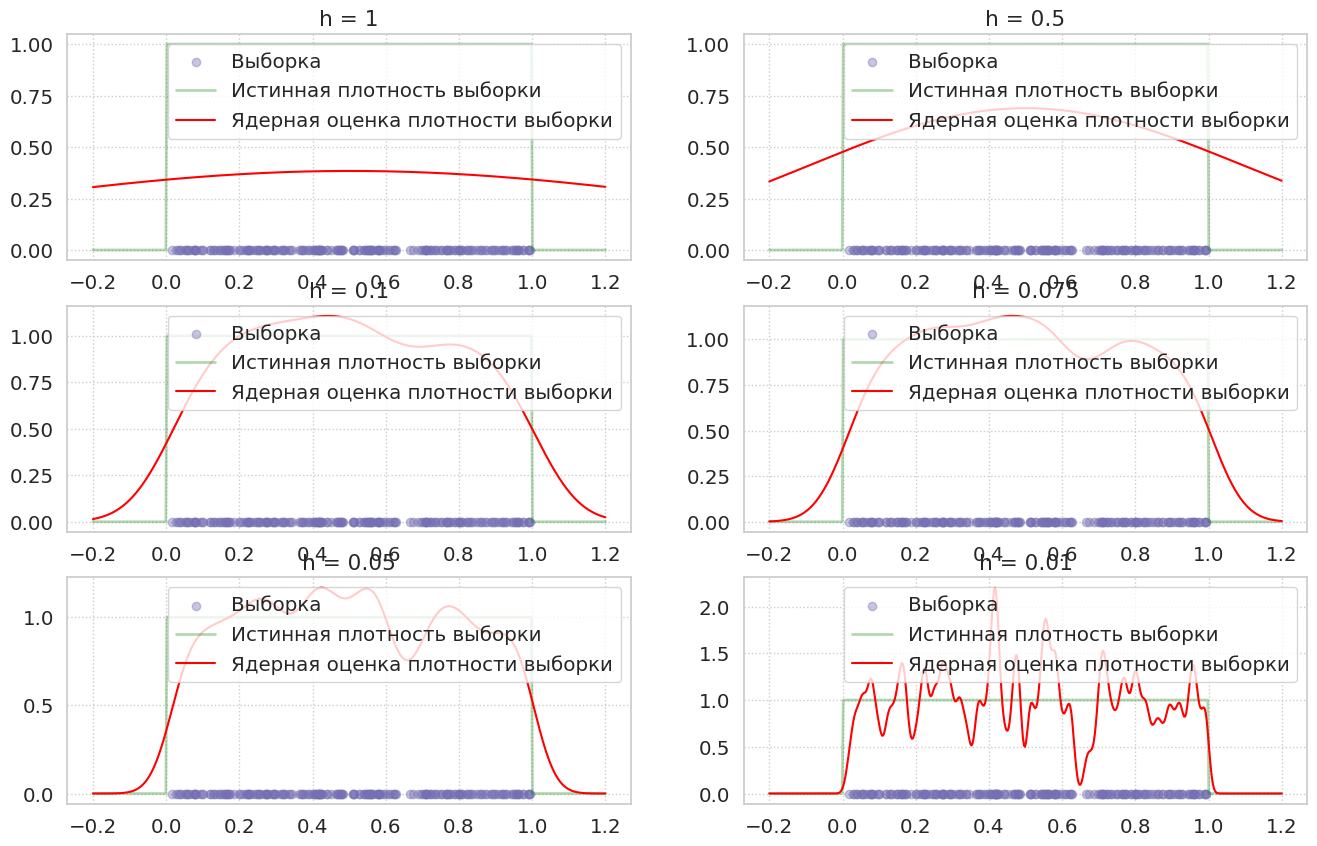

In [33]:
# Размер выборки
size = 200
# Выборка размера size
sample = sps.uniform.rvs(size=size)
# Сетка на отрезке из условия
grid = np.linspace(-0.2, 1.2, 500)

plt.figure(figsize=(16, 10))

# Итераций по ширине ядра
for i, bw in enumerate([1, 0.5, 0.1, 0.075, 0.05, 0.01]):
    plt.subplot(3, 2, i + 1)
    # Построение KDE
    kernel_density = KDEUnivariate(sample).fit(bw=bw)
    # Отображение элементов выборки
    plt.scatter(sample, np.zeros(size), alpha=0.4, label='Выборка')
    # Построение истинной плотности выборки
    plt.plot(grid, sps.uniform.pdf(grid), color='green', 
             alpha=0.3, lw=2, label='Истинная плотность выборки')
    # Отображение KDE плотности
    plt.plot(grid, kernel_density.evaluate(grid), 
             color='red', label='Ядерная оценка плотности выборки')
    plt.legend(loc=1)
    plt.grid(ls=':')
    plt.title('h = {}'.format(bw))
plt.show()

Во втором случае графики постройте аналогичным образом, проведя итерации по типу ядра.

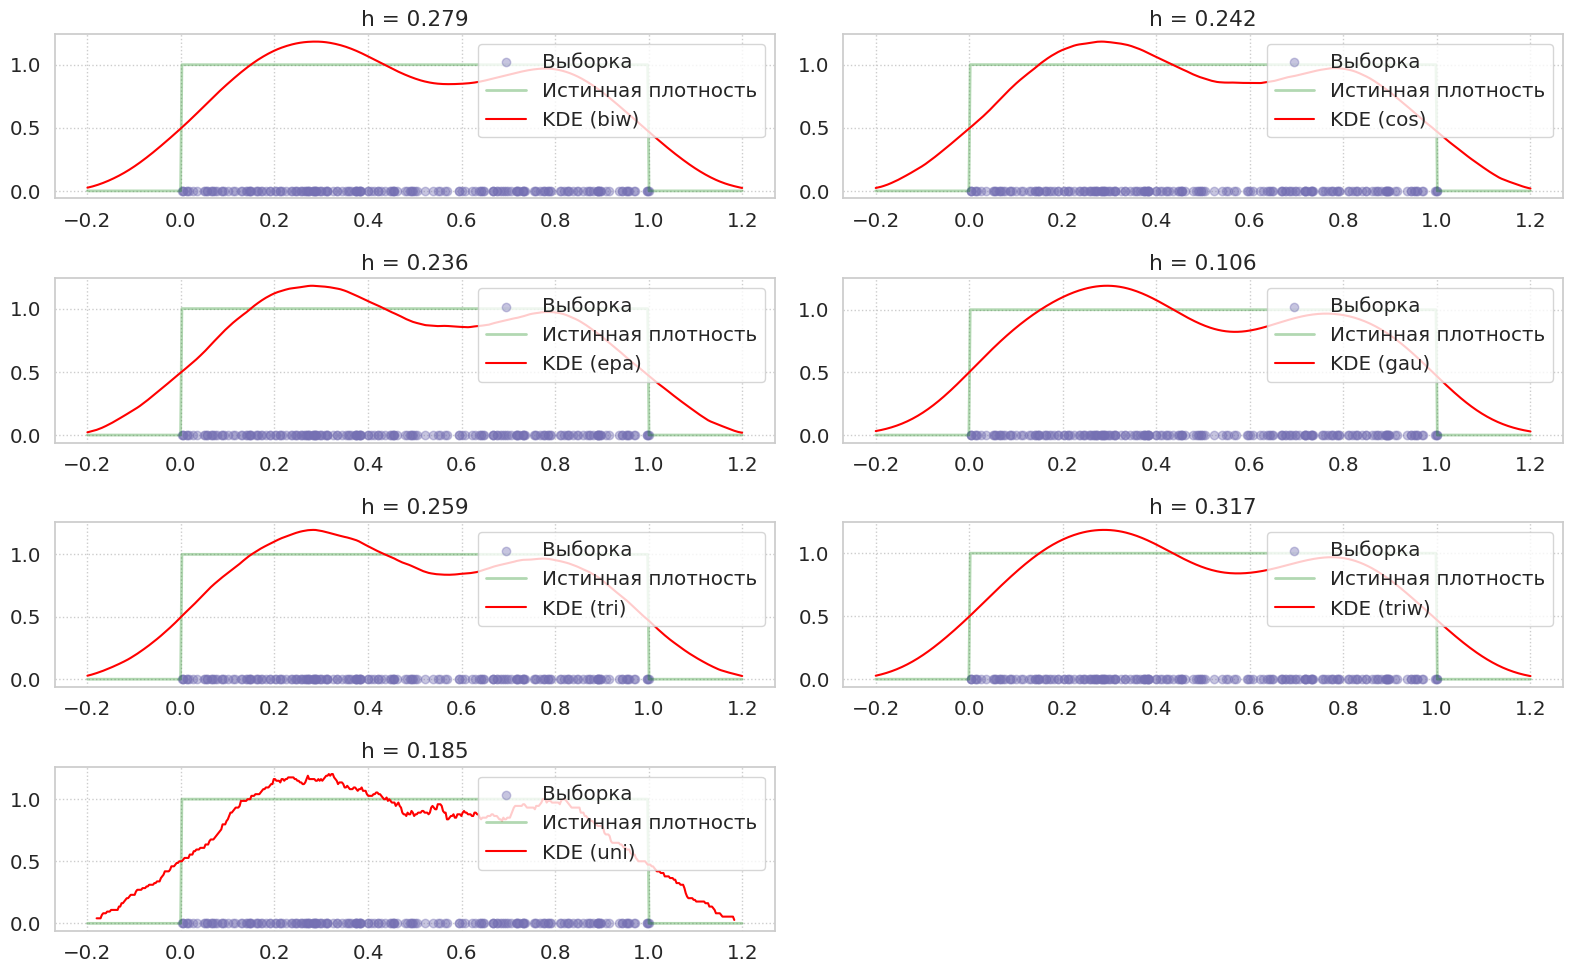

In [64]:
# Размер выборки
size = 200
# Выборка размера size
sample = sps.uniform.rvs(size=size)
# Сетка на отрезке из условия
grid = np.linspace(-0.2, 1.2, 500)

plt.figure(figsize=(16, 10))

bw = 0.05

# Итераций по ширине ядра
for i, kernel in enumerate(['biw', 'cos', 'epa', 'gau', 'tri', 'triw', 'uni']):
    plt.subplot(4, 2, i + 1)
    # Построение KDE
    kernel_density = KDEUnivariate(sample)
    kernel_density.fit(kernel=kernel, fft=False)
    # Отображение элементов выборки
    plt.scatter(sample, np.zeros(size), alpha=0.4, label='Выборка')
    # Построение истинной плотности выборки
    plt.plot(grid, sps.uniform.pdf(grid), color='green', 
             alpha=0.3, lw=2, label='Истинная плотность')
    # Отображение KDE плотности
    plt.plot(grid, np.array([np.asarray(kernel_density.evaluate(x)).ravel()[0] for x in grid]), 
             color='red', label=f'KDE ({kernel})')
    plt.legend(loc=1)
    plt.grid(ls=':')
    plt.title(f'h = {kernel_density.bw:.3f}')

plt.tight_layout()
plt.show()

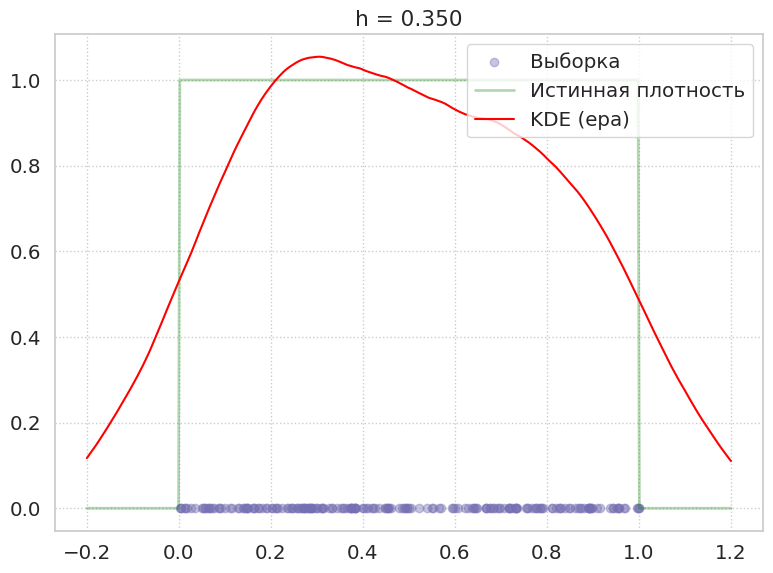

In [69]:
kernel_density = KDEUnivariate(sample)
kernel_density.fit(kernel='epa', fft=False, bw=0.35)
# Отображение элементов выборки
plt.figure(figsize=(8, 6))
plt.scatter(sample, np.zeros(size), alpha=0.4, label='Выборка')
# Построение истинной плотности выборки
plt.plot(grid, sps.uniform.pdf(grid), color='green', 
         alpha=0.3, lw=2, label='Истинная плотность')
# Отображение KDE плотности
plt.plot(grid, np.array([np.asarray(kernel_density.evaluate(x)).ravel()[0] for x in grid]), 
         color='red', label=f'KDE (epa)')
plt.legend(loc=1)
plt.grid(ls=':')
plt.title(f'h = {kernel_density.bw:.3f}')
plt.tight_layout()
plt.show()

**Вывод:**

Видим, что при большой ширине ядра KDE практичесий предсказывает константой, то есть недообучено, а при слишком малой ширине ядра наступает переобучение. Оптимальное для ядра Епанчикова $200^{-0.2} \approx 0.35$ предсказывает неплохо, но по выборке оптимальное окзаалось 0.236. При хорошо подобранном ядре почти все kde предсказывают одинаковую плотность, кроме uniform, которое имею сильный шум

---
### Задача 6.

Рассмотрим задачу регрессии. Мы уже научились оценивать зависимость $y(x)$, но это только точечная оценка для каждого конкретного $x$. На практике бывает необходимо строить доверительные интервалы, которые в совокупности образуют доверительные ленты. Поскольку мы ничего не знаем про распределение ошибок, будем строить доверительную ленту по методу бутстрепа.

1. Сгенерируем достаточно большое число бутстрепных выборок.

2. Обучим модели и получим значения $\widehat{y}(x)$, для всех значений $x$ по сетке значений.

3. По предсказаным значениям оценим верхнюю и нижнюю границы ленты с помощью методов построения бутстрепных доверительных интервалов.

Напишите функцию, которая реализует данный метод

In [ ]:
def bootstrap_confidence_interval(
    X, Y, model, X_grid, bootstrap_count=<...>, alpha=0.95, model_args=None
):
    '''
    Построение предсказательной ленты для модели регрессии.
    
    X, Y - выборка;
    model - класс модели;
    X_grid - сетка для доверительной ленты;
    alpha - уровень доверия;
    bootstrap_count - количество бутстрепных выборок
    model_args - параметры модели.
    '''
    
    predictions = []

    for _ in tqdm(np.arange(bootstap_count)):
        bootstap_model = model(model_args)
        <...>
        predictions.append(bootstrap_model.predict(<...>))

    lower_bound = <...>
    upper_bound = <...>
    return lower_bound, upper_bound

Рассмотрим датасет cps71 

In [ ]:
data = pd.read_csv("cps71.csv", index_col=0)
data.head()

Разделим нашу выборку на обучающую и тестовую

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

Постройте доверительные ленты для моделей линейной регрессии, ядерной регрессии и KNN-регрессии.
Изобразите на графике также предсказания каждой модели и обучающую выборку.

*Примечание: для классов из statmodels сигнатура класса может не совпадать со стандартной, поэтому сделайте для этих классов, класс-обертку, который в себе просто будет вызывать нужные методы.*

Сделайте выводы

**Вывод:**

<...>

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока